In [14]:
!pip install -U datasets huggingface_hub


[notice] A new release of pip is available: 23.0.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [15]:
import os

In [16]:
CARPON = ['/kaggle/input/reptiles-200/all_data/Carbon/Audio',
          '/kaggle/input/reptiles-200/1443 Extracting Carbon Dioxide Sun Mar 17 2024 1710629070792/1443 Extracting Carbon Dioxide Sun Mar 17 2024 1710629070792',
          '/kaggle/input/reptiles-200/1443 Extracting Carbon Dioxide Thu Mar 14 2024 1710422888026/1443 Extracting Carbon Dioxide Thu Mar 14 2024 1710422888026',
          '/kaggle/input/reptiles-200/1443 Extracting Carbon Dioxide Wed Mar 13 2024 1710328578223/1443 Extracting Carbon Dioxide Wed Mar 13 2024 1710328578223',
         ]

REPTILES = ['/kaggle/input/reptiles-200/Reptiles/Reptiles/audio',
            '/kaggle/input/reptiles-200/1444 Reptiles Fri Mar 15 2024 1710499461558/1444 Reptiles Fri Mar 15 2024 1710499461558',
            '/kaggle/input/reptiles-200/1444 Reptiles Sun Mar 17 2024 1710625627081/1444 Reptiles Sun Mar 17 2024 1710625627081',
            '/kaggle/input/reptiles-200/1444 Reptiles Thu Mar 14 2024 1710419290011/1444 Reptiles Thu Mar 14 2024 1710419290011',
            '/kaggle/input/reptiles-200/1444 Reptiles Wed Mar 13 2024 1710325130368/1444 Reptiles Wed Mar 13 2024 1710325130368'
           ]

DIAPERS = ['/kaggle/input/reptiles-200/all_data/Diapers/audio',
           '/kaggle/input/reptiles-200/1445 Diapers Fri Mar 15 2024 1710495969238/1445 Diapers Fri Mar 15 2024 1710495969238',
           '/kaggle/input/reptiles-200/1445 Diapers Sun Mar 17 2024 1710622167857/1445 Diapers Sun Mar 17 2024 1710622167857',
           '/kaggle/input/reptiles-200/1445 Diapers Thu Mar 14 2024 1710415712177/1445 Diapers Thu Mar 14 2024 1710415712177',
           '/kaggle/input/reptiles-200/1445 Diapers Wed Mar 13 2024 1710321713940/1445 Diapers Wed Mar 13 2024 1710321713940'
          ]

In [17]:
import pandas as pd
from tqdm import tqdm 

In [18]:
def organize_data(pathes_list, save_dir=None):
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'{save_dir}.json')
    COLUMN_NAMES = ['name', 'contentScore', 'pronunciationScore', 'fluencyScore', 'totalScore', 'url']
    all_data = list()
    for data_split_path in tqdm(pathes_list):
        iner_files = os.listdir(data_split_path)
        json_file  = [x for x in iner_files if '.json' in x]
        if len(json_file) == 0:
            json_file = 'info.json'
            json_file_path = f'{os.sep}'.join(data_split_path.split(os.sep)[:-1])
            json_file_path = os .path.join(json_file_path, json_file)
        else:
            json_file = json_file[0]
            json_file_path  = os .path.join(data_split_path, json_file)

        json_data = pd.read_json(json_file_path)
        json_data = json_data[[x in iner_files for x in json_data['name']]]
        json_data['name'] = json_data['name'].apply(lambda x: os.path.join(data_split_path, x))
        all_data.append(json_data)
    all_data = pd.concat(all_data, ignore_index=True)
    all_data.to_json(save_path, orient='records')
        

In [19]:
organize_data(CARPON,   'carpon')
organize_data(REPTILES, 'reptiles')
organize_data(DIAPERS,  'diapers')

100%|██████████| 5/5 [00:00<00:00, 59.43it/s]


In [20]:
from datasets import load_dataset, Audio, concatenate_datasets

In [21]:
carpon_data = load_dataset('json', data_files='/kaggle/working/carpon/carpon.json')
carpon_data = carpon_data['train'].train_test_split(train_size=0.77, seed=77).rename_column("name", "audio")

reptiles_data = load_dataset('json', data_files='/kaggle/working/reptiles/reptiles.json')
reptiles_data = reptiles_data['train'].train_test_split(train_size=0.77, seed=77).rename_column("name", "audio")

diapers_data = load_dataset('json', data_files='/kaggle/working/diapers/diapers.json')
diapers_data = diapers_data['train'].train_test_split(train_size=0.77, seed=77).rename_column("name", "audio")

Generating train split: 3101 examples [00:00, 105099.93 examples/s]
Generating train split: 3582 examples [00:00, 114862.36 examples/s]
Generating train split: 3851 examples [00:00, 100056.15 examples/s]


In [22]:
from datasets import DatasetDict, Dataset

In [23]:
data = DatasetDict({'train': None, 'carpon_test': None, 'reptiles_test': None, 'diapers_test': None})

In [24]:
carpon_data

DatasetDict({
    train: Dataset({
        features: ['audio', 'totalScore', 'contentScore', 'fluencyScore', 'url', 'pronunciationScore'],
        num_rows: 2387
    })
    test: Dataset({
        features: ['audio', 'totalScore', 'contentScore', 'fluencyScore', 'url', 'pronunciationScore'],
        num_rows: 714
    })
})

In [25]:
import librosa

In [26]:
def rmove_invalid_data(features):
    audio, sr = librosa.load(features['audio'])
    length = len(audio) / sr
    flag = length >= 8 and length <= 40
    flag = (features['contentScore'] > 9 and features['contentScore'] < 91) or (features['pronunciationScore'] > 9 and features['pronunciationScore'] < 91)
    flag = flag or (features['totalScore'] > 9 and features['totalScore'] < 91) or (features['fluencyScore'] > 9 and features['fluencyScore'] < 91)
    return flag

In [27]:
data

DatasetDict({
    train: None
    carpon_test: None
    reptiles_test: None
    diapers_test: None
})

In [28]:
data['train'] = concatenate_datasets([carpon_data['train'], reptiles_data['train'], diapers_data['train']])
data['carpon_test'] = carpon_data['test']
data['reptiles_test'] = reptiles_data['test']
data['diapers_test'] = diapers_data['test']
data = data.filter(rmove_invalid_data, num_proc=4)
data = data.shuffle(seed=77)

Filter (num_proc=4): 100%|██████████| 886/886 [00:11<00:00, 78.98 examples/s] 


In [29]:
data

DatasetDict({
    train: Dataset({
        features: ['audio', 'totalScore', 'contentScore', 'fluencyScore', 'url', 'pronunciationScore'],
        num_rows: 6534
    })
    carpon_test: Dataset({
        features: ['audio', 'totalScore', 'contentScore', 'fluencyScore', 'url', 'pronunciationScore'],
        num_rows: 574
    })
    reptiles_test: Dataset({
        features: ['audio', 'totalScore', 'contentScore', 'fluencyScore', 'url', 'pronunciationScore'],
        num_rows: 663
    })
    diapers_test: Dataset({
        features: ['audio', 'totalScore', 'contentScore', 'fluencyScore', 'url', 'pronunciationScore'],
        num_rows: 688
    })
})

In [30]:
data = data.cast_column('audio', Audio(16000),)

In [31]:
from  transformers import AutoFeatureExtractor

In [32]:
base_name = 'arslanarjumand/wav2vec-reptiles'

In [33]:
processor = AutoFeatureExtractor.from_pretrained(base_name)

In [34]:
def extract_features(batch):
    batch['length'] = len(batch['audio']["array"]) / batch['audio']["sampling_rate"]
    batch["input_features"] = processor(batch['audio']["array"], sampling_rate=batch['audio']["sampling_rate"], do_normalize=True, return_tensors='pt').input_features[0]
    batch.pop('url')
    batch.pop('audio')
    return batch

In [35]:
cc_data = data.map(extract_features, num_proc=5)

Map (num_proc=5): 100%|██████████| 688/688 [00:57<00:00, 11.89 examples/s]


In [36]:
cc_data

DatasetDict({
    train: Dataset({
        features: ['totalScore', 'contentScore', 'fluencyScore', 'pronunciationScore', 'length', 'input_features'],
        num_rows: 6534
    })
    carpon_test: Dataset({
        features: ['totalScore', 'contentScore', 'fluencyScore', 'pronunciationScore', 'length', 'input_features'],
        num_rows: 574
    })
    reptiles_test: Dataset({
        features: ['totalScore', 'contentScore', 'fluencyScore', 'pronunciationScore', 'length', 'input_features'],
        num_rows: 663
    })
    diapers_test: Dataset({
        features: ['totalScore', 'contentScore', 'fluencyScore', 'pronunciationScore', 'length', 'input_features'],
        num_rows: 688
    })
})

In [37]:
import huggingface_hub
huggingface_hub.login('token')

Token has not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [38]:
cc_data.push_to_hub("arslanarjumand/read_aloud")

Uploading the dataset shards: 100%|██████████| 2/2 [00:16<00:00,  8.28s/it]


CommitInfo(commit_url='https://huggingface.co/datasets/arslanarjumand/read_aloud/commit/dd593522e2fb3fce32b8b651fd3313d45c6daef3', commit_message='Upload dataset', commit_description='', oid='dd593522e2fb3fce32b8b651fd3313d45c6daef3', pr_url=None, pr_revision=None, pr_num=None)

In [25]:
from datasets import load_dataset

In [ ]:
d = load_dataset("arslanarjumand/read_aloud")

In [24]:
# import seaborn as sns
# import matplotlib.pyplot as plt

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

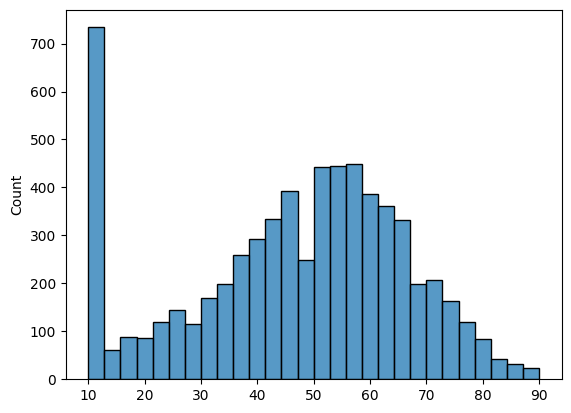

In [26]:
# sns.histplot(cc_data['train']['pronunciationScore'])